In [ ]:
#loading first ds

import kagglehub

# Download latest version
path = kagglehub.dataset_download("whenamancodes/flight-delay-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-delay-prediction' dataset.
Path to dataset files: /kaggle/input/flight-delay-prediction


In [ ]:
#showing first ds

import os

for file in os.listdir(path):
    print(file)


flight_data_2018_to_2022.csv


In [ ]:
import pandas as pd

df1 = pd.read_csv("/root/.cache/kagglehub/datasets/whenamancodes/flight-delay-prediction/versions/1/flight_data_2018_to_2022.csv")
df1.head()

/tmp/ipykernel_4302/2461110374.py:3: DtypeWarning: Columns (11,13,78,85,86,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("/root/.cache/kagglehub/datasets/whenamancodes/flight-delay-prediction/versions/1/flight_data_2018_to_2022.csv")


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [ ]:
rows, columns = df1.shape
print(rows, columns)

563737 120


In [ ]:
df1.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       ...
       'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID', 'Div5WheelsOn',
       'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum',
       'Duplicate', 'Unnamed: 119'],
      dtype='object', length=120)

In [ ]:
#dropping columns
1. #DIVERSION COLUMNS
diversion_columns = [
    'DivAirportLandings', 'DivReachedDest', 'DivActualElapsedTime',
    'DivArrDelay', 'DivDistance',
    'Div1Airport', 'Div1AirportID', 'Div1AirportSeqID', 'Div1WheelsOn',
    'Div1TotalGTime', 'Div1LongestGTime', 'Div1WheelsOff', 'Div1TailNum',
    'Div2Airport', 'Div2AirportID', 'Div2AirportSeqID', 'Div2WheelsOn',
    'Div2TotalGTime', 'Div2LongestGTime', 'Div2WheelsOff', 'Div2TailNum',
    'Div3Airport', 'Div3AirportID', 'Div3AirportSeqID', 'Div3WheelsOn',
    'Div3TotalGTime', 'Div3LongestGTime', 'Div3WheelsOff', 'Div3TailNum',
    'Div4Airport', 'Div4AirportID', 'Div4AirportSeqID', 'Div4WheelsOn',
    'Div4TotalGTime', 'Div4LongestGTime', 'Div4WheelsOff', 'Div4TailNum',
    'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID', 'Div5WheelsOn',
    'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum',
]

# ── 2. LEAKAGE COLUMNS
leakage_columns = [

    'ArrTime',
    'ActualElapsedTime',
    'AirTime',
    'WheelsOn',
    'TaxiIn',


    'ArrDelay',
    'ArrDel15',
    'ArrivalDelayGroups',
    'ArrTimeBlk',


    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay',
    'LateAircraftDelay',


    'FirstDepTime',
    'TotalAddGTime',
    'LongestAddGTime',


    'DepTime',
    'DepDelay',
    'DepDel15',
    'DepartureDelayGroups',


    'TaxiOut',
    'WheelsOff',
]


all_cols_to_drop = diversion_columns + leakage_columns


cols_to_drop = [col for col in all_cols_to_drop if col in df1.columns]
cols_not_found = [col for col in all_cols_to_drop if col not in df1.columns]

if cols_not_found:
    print(f"Not found in dataframe (skipped): {cols_not_found}")

df1_clean = df1.drop(columns=cols_to_drop)

# ── 4. REMOVE DIVERTED AND CANCELLED ROWS
if 'Diverted' in df1_clean.columns:
    before = len(df1_clean)
    df1_clean = df1_clean[df1_clean['Diverted'] != 1]
    print(f"Removed {before - len(df1_clean):,} diverted flights")

if 'Cancelled' in df1_clean.columns:
    before = len(df1_clean)
    df1_clean = df1_clean[df1_clean['Cancelled'] != 1]
    print(f"Removed {before - len(df1_clean):,} cancelled flights")


print("\n")
print(f"Original shape:  {df1.shape}")
print(f"Cleaned shape:   {df1_clean.shape}")
print(f"\nRemaining {len(df1_clean.columns)} columns:")
for col in df1_clean.columns:
    print(f"  {col}")

Removed 1,176 diverted flights
Removed 35,667 cancelled flights


Original shape:  (563737, 120)
Cleaned shape:   (526894, 52)

Remaining 52 columns:
  Year
  Quarter
  Month
  DayofMonth
  DayOfWeek
  FlightDate
  Marketing_Airline_Network
  Operated_or_Branded_Code_Share_Partners
  DOT_ID_Marketing_Airline
  IATA_Code_Marketing_Airline
  Flight_Number_Marketing_Airline
  Originally_Scheduled_Code_Share_Airline
  DOT_ID_Originally_Scheduled_Code_Share_Airline
  IATA_Code_Originally_Scheduled_Code_Share_Airline
  Flight_Num_Originally_Scheduled_Code_Share_Airline
  Operating_Airline 
  DOT_ID_Operating_Airline
  IATA_Code_Operating_Airline
  Tail_Number
  Flight_Number_Operating_Airline
  OriginAirportID
  OriginAirportSeqID
  OriginCityMarketID
  Origin
  OriginCityName
  OriginState
  OriginStateFips
  OriginStateName
  OriginWac
  DestAirportID
  DestAirportSeqID
  DestCityMarketID
  Dest
  DestCityName
  DestState
  DestStateFips
  DestStateName
  DestWac
  CRSDepTime
  DepDelayMin

In [ ]:
# Fix the leftover columns first
df1_clean = df1_clean.drop(
    columns=['Cancelled', 'CancellationCode', 'Diverted', 'Unnamed: 119'],
    errors='ignore'
)

# Check year distribution
print(df1_clean['Year'].value_counts().sort_index())
print(f"Final clean shape: {df1_clean.shape}")

Year
2022    526894
Name: count, dtype: int64
Final clean shape: (526894, 48)


In [ ]:
import pandas as pd
import glob
import os


folder_path = "/root/.cache/kagglehub/datasets/whenamancodes/flight-delay-prediction/versions/1/"


all_files = glob.glob(os.path.join(folder_path, "*.csv"))
print("Files found:")
for f in all_files:
    print(f"  {os.path.basename(f)}")

Files found:
  flight_data_2018_to_2022.csv


In [ ]:
for col in df1_clean.columns:
    print(f"  {col}")

  Year
  Quarter
  Month
  DayofMonth
  DayOfWeek
  FlightDate
  Marketing_Airline_Network
  Operated_or_Branded_Code_Share_Partners
  DOT_ID_Marketing_Airline
  IATA_Code_Marketing_Airline
  Flight_Number_Marketing_Airline
  Originally_Scheduled_Code_Share_Airline
  DOT_ID_Originally_Scheduled_Code_Share_Airline
  IATA_Code_Originally_Scheduled_Code_Share_Airline
  Flight_Num_Originally_Scheduled_Code_Share_Airline
  Operating_Airline 
  DOT_ID_Operating_Airline
  IATA_Code_Operating_Airline
  Tail_Number
  Flight_Number_Operating_Airline
  OriginAirportID
  OriginAirportSeqID
  OriginCityMarketID
  Origin
  OriginCityName
  OriginState
  OriginStateFips
  OriginStateName
  OriginWac
  DestAirportID
  DestAirportSeqID
  DestCityMarketID
  Dest
  DestCityName
  DestState
  DestStateFips
  DestStateName
  DestWac
  CRSDepTime
  DepDelayMinutes
  DepTimeBlk
  CRSArrTime
  ArrDelayMinutes
  CRSElapsedTime
  Flights
  Distance
  DistanceGroup
  Duplicate


In [ ]:
#loading second ds

import kagglehub

# Download latest version
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-delays' dataset.
Path to dataset files: /kaggle/input/flight-delays


In [ ]:
df3_airlines=pd.read_csv(f"{path}/airlines.csv")
df3_airports=pd.read_csv(f"{path}/airports.csv")
df3_flights=pd.read_csv(f"{path}/flights.csv", low_memory=False)

In [ ]:
df3_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [ ]:
df3_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [ ]:
df3_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:


# Check what files are there
print("\nFiles available:")
for f in os.listdir(path):
    print(f"  {f}")

# Load all three files
df3_flights  = pd.read_csv(os.path.join(path, "flights.csv"),
                            dtype=str, low_memory=False)
df3_airports = pd.read_csv(os.path.join(path, "airports.csv"),
                            dtype=str)
df3_airlines = pd.read_csv(os.path.join(path, "airlines.csv"),
                            dtype=str)

print(f"\nFlights shape:  {df3_flights.shape}")
print(f"Airports shape: {df3_airports.shape}")
print(f"Airlines shape: {df3_airlines.shape}")

print("\nFlights columns:")
print(df3_flights.columns.tolist())

print("\nAirports columns:")
print(df3_airports.columns.tolist())

print("\nAirlines columns:")
print(df3_airlines.columns.tolist())


Files available:
  airports.csv
  airlines.csv
  flights.csv

Flights shape:  (5819079, 31)
Airports shape: (322, 7)
Airlines shape: (14, 2)

Flights columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

Airports columns:
['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']

Airlines columns:
['IATA_CODE', 'AIRLINE']


In [ ]:
import pandas as pd
import os

# ── DS3: DROP LEAKAGE COLUMNS
ds3_leakage = [
    'DEPARTURE_TIME',
    'TAXI_OUT',
    'WHEELS_OFF',
    'ELAPSED_TIME',
    'AIR_TIME',
    'WHEELS_ON',
    'TAXI_IN',
    'ARRIVAL_TIME',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]
df3_flights = df3_flights.drop(
    columns=[c for c in ds3_leakage if c in df3_flights.columns]
)
print(f"After dropping leakage: {df3_flights.shape}")

#REMOVE DIVERTED AND CANCELLED ROWS
before = len(df3_flights)
df3_flights = df3_flights[df3_flights['DIVERTED'] != '1']
print(f"Removed {before - len(df3_flights):,} diverted flights")

before = len(df3_flights)
df3_flights = df3_flights[df3_flights['CANCELLED'] != '1']
print(f"Removed {before - len(df3_flights):,} cancelled flights")

df3_flights = df3_flights.drop(
    columns=['DIVERTED', 'CANCELLED', 'CANCELLATION_REASON'],
    errors='ignore'
)

# ADD OriginState AND DestState FROM airports.csv
state_map = df3_airports.set_index('IATA_CODE')['STATE'].to_dict()
df3_flights['OriginState'] = df3_flights['ORIGIN_AIRPORT'].map(state_map)
df3_flights['DestState']   = df3_flights['DESTINATION_AIRPORT'].map(state_map)

#ENGINEER FlightDate
df3_flights['FlightDate'] = pd.to_datetime(
    df3_flights['YEAR'].astype(str) + '-' +
    df3_flights['MONTH'].astype(str).str.zfill(2) + '-' +
    df3_flights['DAY'].astype(str).str.zfill(2),
    errors='coerce'
)

#RENAME TO MATCH DS1
ds3_rename = {
    'YEAR':                'Year',
    'MONTH':               'Month',
    'DAY':                 'DayofMonth',
    'DAY_OF_WEEK':         'DayOfWeek',
    'AIRLINE':             'Marketing_Airline_Network',
    'FLIGHT_NUMBER':       'Flight_Number_Marketing_Airline',
    'TAIL_NUMBER':         'Tail_Number',
    'ORIGIN_AIRPORT':      'Origin',
    'DESTINATION_AIRPORT': 'Dest',
    'SCHEDULED_DEPARTURE': 'CRSDepTime',
    'SCHEDULED_ARRIVAL':   'CRSArrTime',
    'SCHEDULED_TIME':      'CRSElapsedTime',
    'DEPARTURE_DELAY':     'DepDelayMinutes',
    'ARRIVAL_DELAY':       'ArrDelayMinutes',
    'DISTANCE':            'Distance',
}
df3_flights = df3_flights.rename(columns=ds3_rename)

#DEFINE FINAL SHARED SCHEMA
final_cols = [
    'Year',
    'Month',
    'DayofMonth',
    'DayOfWeek',
    'FlightDate',
    'Marketing_Airline_Network',
    'Tail_Number',
    'Origin',
    'OriginState',
    'Dest',
    'DestState',
    'CRSDepTime',
    'CRSArrTime',
    'CRSElapsedTime',
    'DepDelayMinutes',
    'Distance',
    'ArrDelayMinutes',  # TARGET
]


df3_clean = df3_flights[[c for c in final_cols if c in df3_flights.columns]].copy()
df1_final = df1_clean[[c for c in final_cols if c in df1_clean.columns]].copy()

print(f"\nDS3 missing from schema: {[c for c in final_cols if c not in df3_flights.columns]}")
print(f"DS1 missing from schema: {[c for c in final_cols if c not in df1_clean.columns]}")


df3_clean['source'] = 'DS3_2015'
df1_final['source'] = 'DS1_2022'


combined = pd.concat([df3_clean, df1_final], ignore_index=True)


print("\n")
print(f"DS3 cleaned shape:  {df3_clean.shape}")
print(f"DS1 cleaned shape:  {df1_final.shape}")
print(f"Combined shape:     {combined.shape}")

print(f"\nYear distribution:")
print(combined['Year'].value_counts().sort_index())

print(f"\nNull counts:")
print(combined.isnull().sum())

print(f"\nData types:")
print(combined.dtypes)

print(f"\nFirst few rows:")
print(combined.head())

After dropping leakage: (5819079, 18)
Removed 15,187 diverted flights
Removed 89,884 cancelled flights

DS3 missing from schema: []
DS1 missing from schema: []


DS3 cleaned shape:  (5714008, 18)
DS1 cleaned shape:  (526894, 18)
Combined shape:     (6240902, 18)

Year distribution:


TypeError: '<' not supported between instances of 'int' and 'str'

In [ ]:

combined['Year'] = pd.to_numeric(combined['Year'], errors='coerce').astype('Int64')

# converting numeric columns
numeric_cols = [
    'Year', 'Month', 'DayofMonth', 'DayOfWeek',
    'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime',
    'DepDelayMinutes', 'ArrDelayMinutes', 'Distance'
]
for col in numeric_cols:
    combined[col] = pd.to_numeric(combined[col], errors='coerce')

# FlightDate to datetime
combined['FlightDate'] = pd.to_datetime(combined['FlightDate'], errors='coerce')

# Now re-run the verification
print(f"Combined shape: {combined.shape}")

print(f"\nYear distribution:")
print(combined['Year'].value_counts().sort_index())

print(f"\nNull counts:")
print(combined.isnull().sum())

print(f"\nData types:")
print(combined.dtypes)




Combined shape: (6240902, 18)

Year distribution:
Year
2015    5714008
2022     526894
Name: count, dtype: Int64

Null counts:
Year                              0
Month                             0
DayofMonth                        0
DayOfWeek                         0
FlightDate                        0
Marketing_Airline_Network         0
Tail_Number                       0
Origin                            0
OriginState                  482878
Dest                              0
DestState                    482878
CRSDepTime                        0
CRSArrTime                        0
CRSElapsedTime                    0
DepDelayMinutes                   0
Distance                          0
ArrDelayMinutes                   0
source                            0
dtype: int64

Data types:
Year                                  Int64
Month                                 int64
DayofMonth                            int64
DayOfWeek                             int64
FlightDate             

In [ ]:
#airports unmatched
unmatched_origin = combined[combined['OriginState'].isna()]['Origin'].value_counts()
unmatched_dest   = combined[combined['DestState'].isna()]['Dest'].value_counts()

print("Top unmatched origin airports:")
print(unmatched_origin.head(20))

print("\nTop unmatched destination airports:")
print(unmatched_dest.head(20))

print(f"\nTotal unique unmatched origins: {unmatched_origin.shape[0]}")
print(f"Total unique unmatched dests:   {unmatched_dest.shape[0]}")

# Check nulls
print("\nNulls by source:")
print(combined[combined['OriginState'].isna()]['source'].value_counts())

Top unmatched origin airports:
Origin
10397    32509
13930    27566
11298    20586
11292    18077
12892    17628
14771    14094
12266    13091
14107    12884
12889    12649
13487    10552
14747    10361
10721    10091
11433     9882
11057     9537
11618     9508
13204     9006
14869     8738
12953     8447
12478     8255
10821     7991
Name: count, dtype: int64

Top unmatched destination airports:
Dest
10397    32546
13930    27506
11298    20461
11292    18065
12892    17647
14771    14083
12266    13072
14107    12884
12889    12664
13487    10600
14747    10350
10721    10094
11433     9880
11618     9539
11057     9535
13204     9022
14869     8737
12953     8431
12478     8235
10821     7990
Name: count, dtype: int64

Total unique unmatched origins: 306
Total unique unmatched dests:   307

Nulls by source:
source
DS3_2015    482878
Name: count, dtype: int64


In [ ]:
# Check what DS1 has for these same airports
# DS1 has both Origin (IATA) and OriginAirportID (numeric) — use it as a lookup
ds1_origin_lookup = df1_clean[['OriginAirportID', 'Origin', 'OriginState']].drop_duplicates()
ds1_dest_lookup   = df1_clean[['DestAirportID', 'Dest', 'DestState']].drop_duplicates()

print("DS1 origin lookup sample:")
print(ds1_origin_lookup.head(10))
print(f"Unique origin airport IDs in DS1: {ds1_origin_lookup.shape[0]}")

DS1 origin lookup sample:
    OriginAirportID Origin OriginState
1             10397    ATL          GA
2             11697    FLL          FL
5             12448    JAN          MS
6             14524    RIC          VA
7             13487    MSP          MN
9             14492    RDU          NC
10            10693    BNA          TN
12            12339    IND          IN
13            12953    LGA          NY
15            14685    SAV          GA
Unique origin airport IDs in DS1: 369


In [ ]:
#using DS1 to fill DS2 gap for OriginAirportID and OriginState


numeric_to_origin_state = ds1_origin_lookup.set_index(
    'OriginAirportID'
)['OriginState'].to_dict()

numeric_to_dest_state = ds1_dest_lookup.set_index(
    'DestAirportID'
)['DestState'].to_dict()


numeric_to_origin_state = {str(k): v for k, v in numeric_to_origin_state.items()}

numeric_to_dest_state   = {str(k): v for k, v in numeric_to_dest_state.items()}


mask_origin = combined['OriginState'].isna()

mask_dest   = combined['DestState'].isna()

combined.loc[mask_origin, 'OriginState'] = combined.loc[
    mask_origin, 'Origin'
].map(numeric_to_origin_state)

combined.loc[mask_dest, 'DestState'] = combined.loc[
    mask_dest, 'Dest'
].map(numeric_to_dest_state)

print(f"Remaining OriginState nulls: {combined['OriginState'].isna().sum():,}")
print(f"Remaining DestState nulls:   {combined['DestState'].isna().sum():,}")

Remaining OriginState nulls: 273
Remaining DestState nulls:   269


In [ ]:

still_null = combined['OriginState'].isna().sum()
print(f"Still null after lookup: {still_null:,}")

if still_null > 0:

    if still_null / len(combined) < 0.01:  # less than 1%
        combined = combined.dropna(subset=['OriginState', 'DestState'])
        print(f"Dropped remaining null rows. New shape: {combined.shape}")


    else:
        combined['OriginState'] = combined['OriginState'].fillna('UNKNOWN')
        combined['DestState']   = combined['DestState'].fillna('UNKNOWN')
        print("Filled remaining nulls with UNKNOWN")

Still null after lookup: 273
Dropped remaining null rows. New shape: (6240360, 18)


In [ ]:
print("Final null check:")
print(combined.isnull().sum())

print(f"\nDataset summary:")
print(combined.describe())


Final null check:
Year                         0
Month                        0
DayofMonth                   0
DayOfWeek                    0
FlightDate                   0
Marketing_Airline_Network    0
Tail_Number                  0
Origin                       0
OriginState                  0
Dest                         0
DestState                    0
CRSDepTime                   0
CRSArrTime                   0
CRSElapsedTime               0
DepDelayMinutes              0
Distance                     0
ArrDelayMinutes              0
source                       0
dtype: int64

Dataset summary:
              Year         Month    DayofMonth     DayOfWeek  \
count    6240360.0  6.240360e+06  6.240360e+06  6.240360e+06   
mean   2015.591033  6.079081e+00  1.574843e+01  3.939035e+00   
min         2015.0  1.000000e+00  1.000000e+00  1.000000e+00   
25%         2015.0  3.000000e+00  8.000000e+00  2.000000e+00   
50%         2015.0  6.000000e+00  1.600000e+01  4.000000e+00   
75%      

In [ ]:
#data cleaning


# dropping negative elapsed time
before = len(combined)
combined = combined[combined['CRSElapsedTime'] > 0]
print(f"Removed {before - len(combined):,} rows with invalid elapsed time")
combined['DepDelayMinutes'] = combined['DepDelayMinutes'].clip(lower=0)
combined['ArrDelayMinutes'] = combined['ArrDelayMinutes'].clip(lower=0)

print(f"\nAfter clipping negatives:")
print(f"DepDelayMinutes min: {combined['DepDelayMinutes'].min()}")
print(f"ArrDelayMinutes min: {combined['ArrDelayMinutes'].min()}")


combined['CRSArrTime'] = combined['CRSArrTime'].replace(2400, 0)

#HANDLE OUTLIERS IN TARGET

print(f"\nArrDelayMinutes percentiles:")
print(combined['ArrDelayMinutes'].quantile([0.90, 0.95, 0.99, 0.999]))


cap_value = combined['ArrDelayMinutes'].quantile(0.99)
print(f"\nCapping ArrDelayMinutes at 99th percentile: {cap_value} minutes")
combined['ArrDelayMinutes'] = combined['ArrDelayMinutes'].clip(upper=cap_value)


dep_cap = combined['DepDelayMinutes'].quantile(0.99)
print(f"Capping DepDelayMinutes at 99th percentile: {dep_cap} minutes")
combined['DepDelayMinutes'] = combined['DepDelayMinutes'].clip(upper=dep_cap)


combined = combined.drop(columns=['source'])


print(f"\n{'='*50}")
print(f"Final shape: {combined.shape}")
print(f"\nYear distribution:")
print(combined['Year'].value_counts().sort_index())
print(f"\nUpdated stats:")
print(combined[['CRSElapsedTime', 'DepDelayMinutes',
                'ArrDelayMinutes', 'Distance']].describe())
print(f"\nNull check:")
print(combined.isnull().sum())

Removed 1 rows with invalid elapsed time

After clipping negatives:
DepDelayMinutes min: 0.0
ArrDelayMinutes min: 0.0

ArrDelayMinutes percentiles:
0.900     35.0
0.950     67.0
0.990    169.0
0.999    382.0
Name: ArrDelayMinutes, dtype: float64

Capping ArrDelayMinutes at 99th percentile: 169.0 minutes
Capping DepDelayMinutes at 99th percentile: 170.0 minutes

Final shape: (6240359, 17)

Year distribution:
Year
2015    5713466
2022     526893
Name: count, dtype: Int64

Updated stats:
       CRSElapsedTime  DepDelayMinutes  ArrDelayMinutes      Distance
count    6.240359e+06     6.240359e+06     6.240359e+06  6.240359e+06
mean     1.421323e+02     1.130086e+01     1.132782e+01  8.227191e+02
std      7.506443e+01     2.823771e+01     2.812751e+01  6.071576e+02
min      1.800000e+01     0.000000e+00     0.000000e+00  3.100000e+01
25%      8.600000e+01     0.000000e+00     0.000000e+00  3.730000e+02
50%      1.230000e+02     0.000000e+00     0.000000e+00  6.500000e+02
75%      1.740000e+0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Current columns:")
for col in combined.columns:
    print(f"  {col}")


Current columns:
  Year
  Month
  DayofMonth
  DayOfWeek
  FlightDate
  Marketing_Airline_Network
  Tail_Number
  Origin
  OriginState
  Dest
  DestState
  CRSDepTime
  CRSArrTime
  CRSElapsedTime
  DepDelayMinutes
  Distance
  ArrDelayMinutes


admin/Id columns preprocessing:
admin/ID columns were dropped based on:
1. domain knowledge rationale that these are arbitrary database keys with no operational significance
2. the claim above was supported through pearson correlation

Admin and identifier columns such as DOT airline IDs, airport sequence IDs, and geographic area codes were evaluated using Pearson correlation against the target variable ArrDelayMinutes

Correlation of admin/ID columns with ArrDelayMinutes:
                  Column  Abs_Correlation
        DestCityMarketID         0.001046
      OriginCityMarketID         0.002817
           DestAirportID         0.003084
         OriginAirportID         0.007417
           DestStateFips         0.007679
         OriginStateFips         0.009623
                 DestWac         0.029908
               OriginWac         0.032232
DOT_ID_Operating_Airline         0.058852
DOT_ID_Marketing_Airline         0.059895
                 Flights              NaN


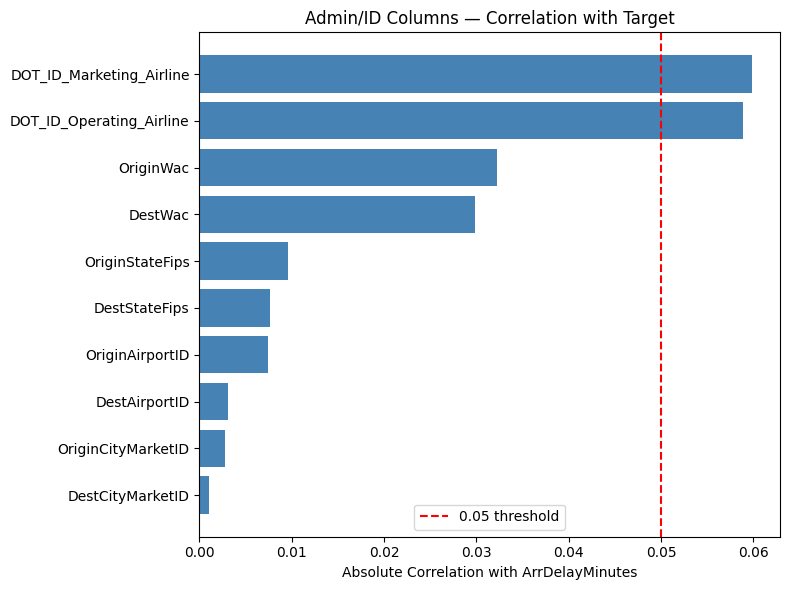

In [ ]:

admin_cols_in_ds1 = [
    'DOT_ID_Marketing_Airline',
    'DOT_ID_Operating_Airline',
    'OriginAirportID',
    'DestAirportID',
    'OriginCityMarketID',
    'DestCityMarketID',
    'OriginStateFips',
    'DestStateFips',
    'OriginWac',
    'DestWac',
    'Flights',
]


ds1_admin_analysis = df1_clean[admin_cols_in_ds1 + ['ArrDelayMinutes']].copy()
ds1_admin_analysis = ds1_admin_analysis.apply(pd.to_numeric, errors='coerce')


corr = ds1_admin_analysis.corr()['ArrDelayMinutes'].drop('ArrDelayMinutes')
corr_df = corr.abs().sort_values(ascending=True).reset_index()
corr_df.columns = ['Column', 'Abs_Correlation']

print("Correlation of admin/ID columns with ArrDelayMinutes:")
print(corr_df.to_string(index=False))


plt.figure(figsize=(8, 6))
plt.barh(corr_df['Column'], corr_df['Abs_Correlation'], color='steelblue')
plt.axvline(x=0.05, color='red', linestyle='--', label='0.05 threshold')
plt.xlabel('Absolute Correlation with ArrDelayMinutes')
plt.title('Admin/ID Columns — Correlation with Target')
plt.legend()
plt.tight_layout()
plt.show()

#VIF redundancy analysis

VIF redundancy analysis on current 17 columns. The candidates for redundancy are:
CRSDepTime    ←→  CRSArrTime      (both scheduled times, likely correlated)
CRSElapsedTime ←→ Distance        (longer distance = longer flight, likely correlated)
Month         ←→  DayofMonth      (both temporal)

VIF Results:
        Feature       VIF
 CRSElapsedTime 97.639545
       Distance 65.085974
     CRSArrTime 19.176440
     CRSDepTime 16.819613
      DayOfWeek  4.323312
     DayofMonth  3.750794
          Month  3.442947
DepDelayMinutes  1.184874


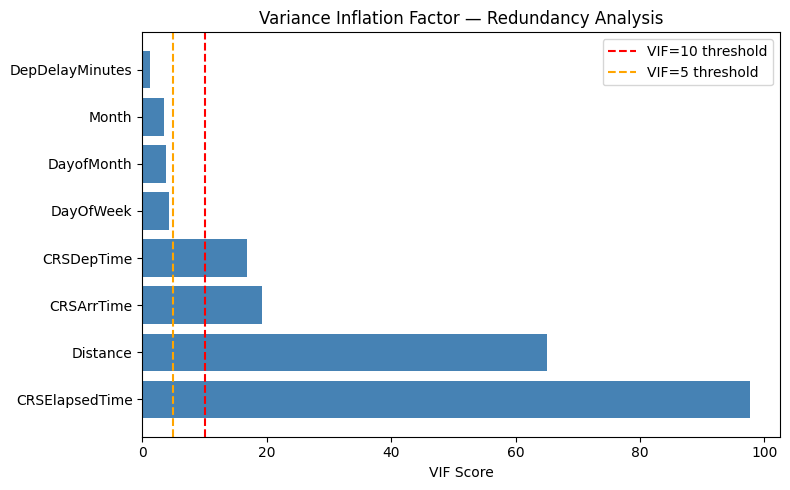

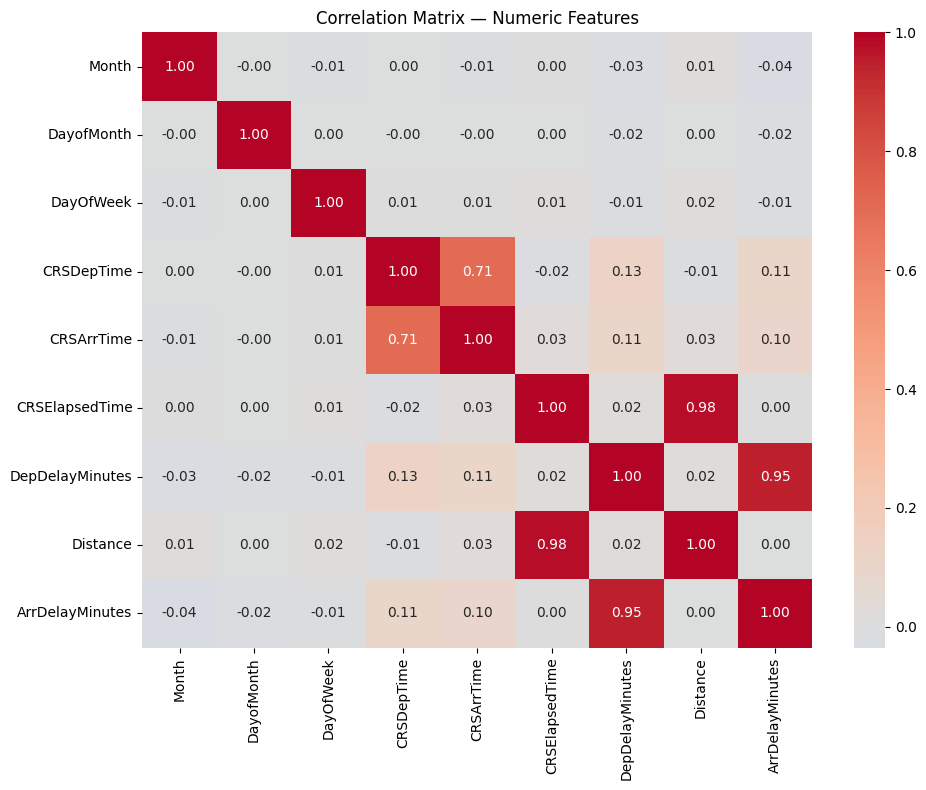

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


numeric_cols = [
    'Month', 'DayofMonth', 'DayOfWeek',
    'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime',
    'DepDelayMinutes', 'Distance'
]

vif_data = combined[numeric_cols].dropna().sample(
    100000, random_state=42  # sample for speed
)

vif_results = pd.DataFrame()
vif_results['Feature'] = numeric_cols
vif_results['VIF'] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(len(numeric_cols))
]
vif_results = vif_results.sort_values('VIF', ascending=False)

print("VIF Results:")
print(vif_results.to_string(index=False))


plt.figure(figsize=(8, 5))
plt.barh(vif_results['Feature'], vif_results['VIF'], color='steelblue')
plt.axvline(x=10, color='red', linestyle='--', label='VIF=10 threshold')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF=5 threshold')
plt.xlabel('VIF Score')
plt.title('Variance Inflation Factor — Redundancy Analysis')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
corr_matrix = combined[numeric_cols + ['ArrDelayMinutes']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
combined = combined.drop(columns=['CRSElapsedTime', 'CRSArrTime'])

# Re-run VIF to confirm improvement
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = [
    'Month', 'DayofMonth', 'DayOfWeek',
    'CRSDepTime', 'DepDelayMinutes', 'Distance'
]

vif_data = combined[numeric_cols].dropna().sample(100000, random_state=42)

vif_results = pd.DataFrame()
vif_results['Feature'] = numeric_cols
vif_results['VIF'] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(len(numeric_cols))
]
vif_results = vif_results.sort_values('VIF', ascending=False)

print("Updated VIF Results:")
print(vif_results.to_string(index=False))


Updated VIF Results:
        Feature      VIF
     CRSDepTime 5.557560
      DayOfWeek 3.986071
     DayofMonth 3.495713
          Month 3.304293
       Distance 2.577630
DepDelayMinutes 1.182476


##Updated Column List After VIF
```
Year, Month, DayofMonth, DayOfWeek, FlightDate
Marketing_Airline_Network, Tail_Number
Origin, OriginState, Dest, DestState
CRSDepTime
DepDelayMinutes, Distance
ArrDelayMinutes  ← target

15 columns total

##encoding categorical columns followed by normalisation of numeric columns.

Categorical columns are encoded,
Marketing_Airline_Network  — ~20 unique carriers
Tail_Number                — thousands of unique aircraft
Origin                     — ~500 unique airports
OriginState                — ~50 states
Dest                       — ~500 unique airports
DestState                  — ~50 states

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder


combined['dep_hour'] = combined['CRSDepTime'] // 100
combined = combined.drop(columns=['CRSDepTime'])


combined = combined.drop(columns=['FlightDate'])

print("Columns before encoding:")
print(combined.columns.tolist())


high_cardinality = ['Origin', 'Dest', 'Tail_Number']

for col in high_cardinality:
    print(f"\n{col} unique values: {combined[col].nunique()}")
    means = combined.groupby(col)['ArrDelayMinutes'].mean()
    combined[f'{col}_encoded'] = combined[col].map(means)
    combined = combined.drop(columns=[col])


low_cardinality = ['Marketing_Airline_Network', 'OriginState', 'DestState']

le = LabelEncoder()
for col in low_cardinality:
    print(f"\n{col} unique values: {combined[col].nunique()}")
    combined[col] = le.fit_transform(combined[col].astype(str))

print("\nAfter encoding:")
print(combined.dtypes)
print(f"\nShape: {combined.shape}")
print(f"\nNull check:")
print(combined.isnull().sum())

Columns before encoding:
['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Tail_Number', 'Origin', 'OriginState', 'Dest', 'DestState', 'DepDelayMinutes', 'Distance', 'ArrDelayMinutes', 'dep_hour']

Origin unique values: 681

Dest unique values: 682

Tail_Number unique values: 7795

Marketing_Airline_Network unique values: 15

OriginState unique values: 55

DestState unique values: 55

After encoding:
Year                           Int64
Month                          int64
DayofMonth                     int64
DayOfWeek                      int64
Marketing_Airline_Network      int64
OriginState                    int64
DestState                      int64
DepDelayMinutes              float64
Distance                     float64
ArrDelayMinutes              float64
dep_hour                       int64
Origin_encoded               float64
Dest_encoded                 float64
Tail_Number_encoded          float64
dtype: object

Shape: (6240359, 14)

Null check:
Year

##normalising after encoding

In [ ]:

# Separate target before scaling
target = combined['ArrDelayMinutes']
features = combined.drop(columns=['ArrDelayMinutes'])

# Columns to scale
scale_cols = [
    'dep_hour', 'Distance', 'DepDelayMinutes',
    'Month', 'DayofMonth', 'DayOfWeek',
    'Origin_encoded', 'Dest_encoded', 'Tail_Number_encoded'
]

scaler = StandardScaler()
features[scale_cols] = scaler.fit_transform(features[scale_cols])


combined_final = pd.concat([features, target], axis=1)

print("\nFinal dataset:")
print(combined_final.shape)
print(combined_final.head())
print("\nFinal dtypes:")
print(combined_final.dtypes)


Final dataset:
(6240359, 14)
   Year     Month  DayofMonth  DayOfWeek  Marketing_Airline_Network  \
0  2015 -1.411572   -1.678986   0.030577                          1   
1  2015 -1.411572   -1.678986   0.030577                          0   
2  2015 -1.411572   -1.678986   0.030577                         12   
3  2015 -1.411572   -1.678986   0.030577                          0   
4  2015 -1.411572   -1.678986   0.030577                          1   

   OriginState  DestState  DepDelayMinutes  Distance  dep_hour  \
0            0         51        -0.400205  1.029849 -2.701927   
1            5          9        -0.400205  2.482520 -2.701927   
2            5         28        -0.400205  2.426521 -2.701927   
3            5          9        -0.400205  2.502284 -2.701927   
4           51          0        -0.400205  1.029849 -2.701927   

   Origin_encoded  Dest_encoded  Tail_Number_encoded  ArrDelayMinutes  
0       -1.578604     -0.717453            -1.502502              0.0  
1 

In [ ]:
# Scale the label encoded columns too
label_encoded_cols = ['Marketing_Airline_Network', 'OriginState', 'DestState']

combined_final[label_encoded_cols] = scaler.fit_transform(
    combined_final[label_encoded_cols]
)

print("Fixed scaling:")
print(combined_final[label_encoded_cols].describe())

Fixed scaling:
       Marketing_Airline_Network   OriginState     DestState
count               6.240359e+06  6.240359e+06  6.240359e+06
mean                5.552845e-17  7.352783e-17  9.823144e-17
std                 1.000000e+00  1.000000e+00  1.000000e+00
min                -1.391625e+00 -1.467841e+00 -1.467823e+00
25%                -8.082239e-01 -9.091192e-01 -9.090689e-01
50%                 1.641115e-01 -1.641572e-01 -1.640639e-01
75%                 9.419798e-01  8.912057e-01  8.913599e-01
max                 1.330914e+00  1.884488e+00  1.884700e+00


In [ ]:
print(f"Shape: {combined_final.shape}")
print(f"\nYear distribution (for split later):")
print(combined_final['Year'].value_counts().sort_index())
print(f"\nAll numeric check:")
print(combined_final.dtypes)
print(f"\nNull check:")
print(combined_final.isnull().sum())
print(f"\nTarget distribution:")
print(combined_final['ArrDelayMinutes'].describe())

Shape: (6240359, 14)

Year distribution (for split later):
Year
2015    5713466
2022     526893
Name: count, dtype: Int64

All numeric check:
Year                           Int64
Month                        float64
DayofMonth                   float64
DayOfWeek                    float64
Marketing_Airline_Network    float64
OriginState                  float64
DestState                    float64
DepDelayMinutes              float64
Distance                     float64
dep_hour                     float64
Origin_encoded               float64
Dest_encoded                 float64
Tail_Number_encoded          float64
ArrDelayMinutes              float64
dtype: object

Null check:
Year                         0
Month                        0
DayofMonth                   0
DayOfWeek                    0
Marketing_Airline_Network    0
OriginState                  0
DestState                    0
DepDelayMinutes              0
Distance                     0
dep_hour                     0
Ori

#sampling



In [ ]:

# Keeping proportional representation of 2015 and 2022

ds_2015 = combined_final[combined_final['Year'] == 2015]
ds_2022 = combined_final[combined_final['Year'] == 2022]

print(f"2015 full size: {len(ds_2015):,}")
print(f"2022 full size: {len(ds_2022):,}")

# Sample 500k from 2015, keeping all of 2022
ds_2015_sampled = ds_2015.sample(n=500000, random_state=42)

print(f"\n2015 sampled: {len(ds_2015_sampled):,}")
print(f"2022 kept:    {len(ds_2022):,}")


combined_sampled = pd.concat([ds_2015_sampled, ds_2022], ignore_index=True)

print(f"\nFinal sampled shape: {combined_sampled.shape}")
print(f"\nYear distribution after sampling:")
print(combined_sampled['Year'].value_counts().sort_index())


print(f"\nTarget distribution after sampling:")
print(combined_sampled['ArrDelayMinutes'].describe())


print(f"\n% zero delay (on time): {(combined_sampled['ArrDelayMinutes'] == 0).mean():.1%}")
print(f"% delayed >15 mins:     {(combined_sampled['ArrDelayMinutes'] > 15).mean():.1%}")
print(f"% delayed >60 mins:     {(combined_sampled['ArrDelayMinutes'] > 60).mean():.1%}")

2015 full size: 5,713,466
2022 full size: 526,893

2015 sampled: 500,000
2022 kept:    526,893

Final sampled shape: (1026893, 14)

Year distribution after sampling:
Year
2015    500000
2022    526893
Name: count, dtype: Int64

Target distribution after sampling:
count    1.026893e+06
mean     1.187118e+01
std      2.944402e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      8.000000e+00
max      1.690000e+02
Name: ArrDelayMinutes, dtype: float64

% zero delay (on time): 65.1%
% delayed >15 mins:     18.4%
% delayed >60 mins:     6.2%


#train/test split and modelling

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


train = combined_sampled[combined_sampled['Year'] == 2015]
test  = combined_sampled[combined_sampled['Year'] == 2022]


X_train = train.drop(columns=['Year', 'ArrDelayMinutes'])
y_train = train['ArrDelayMinutes']

X_test  = test.drop(columns=['Year', 'ArrDelayMinutes'])
y_test  = test['ArrDelayMinutes']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train mean:  {y_train.mean():.2f} mins")
print(f"y_test mean:   {y_test.mean():.2f} mins")

#linear regression
print("\n")
print("Model 1: Linear Regression (Baseline)")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"  MAE:  {mae_lr:.2f} mins")
print(f"  RMSE: {rmse_lr:.2f} mins")
print(f"  R²:   {r2_lr:.4f}")

#random forest
print("\n")
print("Model 2: Random Forest Regressor")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,        # limit depth for speed
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"  MAE:  {mae_rf:.2f} mins")
print(f"  RMSE: {rmse_rf:.2f} mins")
print(f"  R²:   {r2_rf:.4f}")

#xgboost
print("\n")
print("Model 3: XGBoost Regressor")
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)

y_pred_xgb = xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"  MAE:  {mae_xgb:.2f} mins")
print(f"  RMSE: {rmse_xgb:.2f} mins")
print(f"  R²:   {r2_xgb:.4f}")


print("\n")
print("Model Comparison:")
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE':   [mae_lr,  mae_rf,  mae_xgb],
    'RMSE':  [rmse_lr, rmse_rf, rmse_xgb],
    'R²':    [r2_lr,   r2_rf,   r2_xgb]
})
print(results.to_string(index=False))

X_train shape: (500000, 12)
X_test shape:  (526893, 12)
y_train mean:  11.24 mins
y_test mean:   12.47 mins

Model 1: Linear Regression (Baseline)
  MAE:  5.17 mins
  RMSE: 9.81 mins
  R²:   0.8986

Model 2: Random Forest Regressor
  MAE:  5.14 mins
  RMSE: 9.60 mins
  R²:   0.9031

Model 3: XGBoost Regressor
[0]	validation_0-rmse:28.04374
[50]	validation_0-rmse:9.57917
[100]	validation_0-rmse:9.60486
[150]	validation_0-rmse:9.61118
[199]	validation_0-rmse:9.63237
  MAE:  5.13 mins
  RMSE: 9.63 mins
  R²:   0.9023

Model Comparison:
            Model      MAE     RMSE       R²
Linear Regression 5.172933 9.814698 0.898590
    Random Forest 5.143671 9.595230 0.903075
          XGBoost 5.133263 9.632371 0.902323


#SHAP feature importance

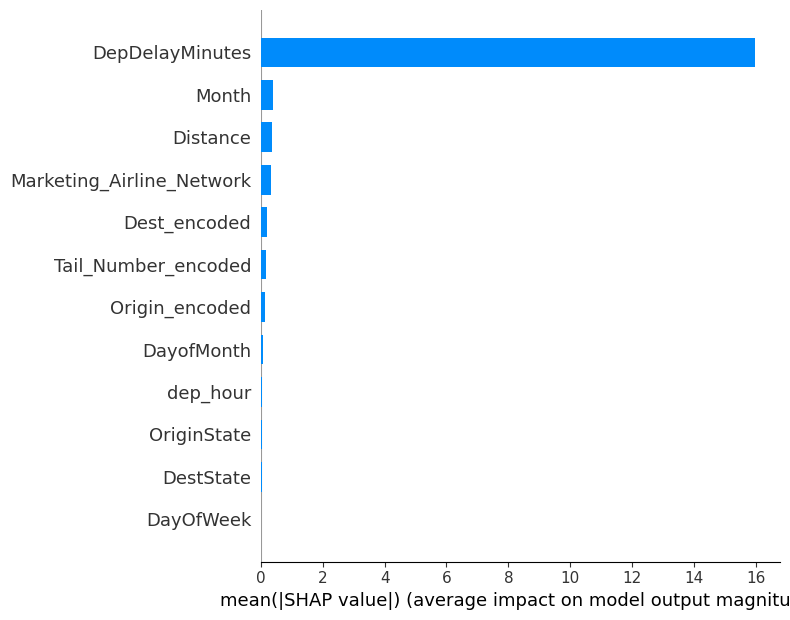

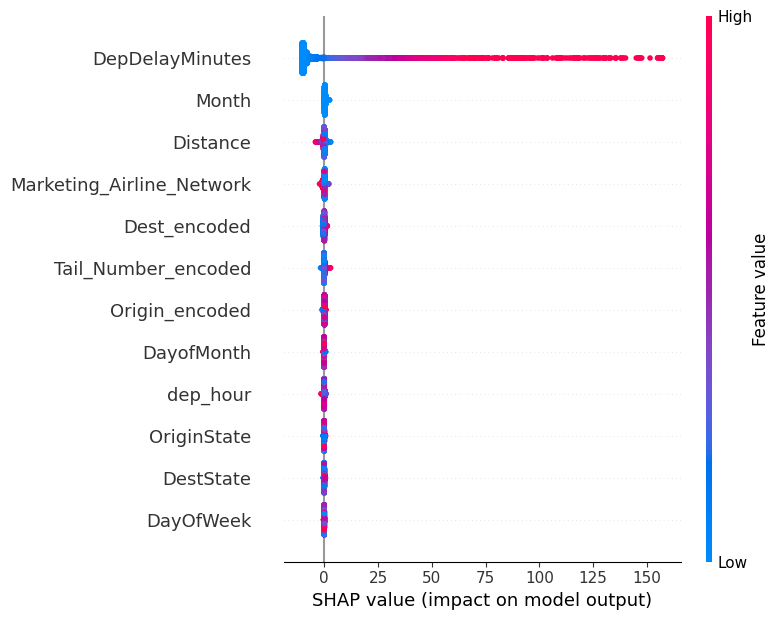

In [ ]:
import shap
import matplotlib.pyplot as plt

#Using random forest as it performed best
explainer = shap.TreeExplainer(rf)


X_test_sample = X_test.sample(5000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)


shap.summary_plot(shap_values, X_test_sample,
                  plot_type='bar',
                  title='Feature Importance — Random Forest')


shap.summary_plot(shap_values, X_test_sample)

In [ ]:
#dropping OriginState and DestState according to SHAP
X_train_reduced = X_train.drop(columns=['OriginState', 'DestState'])
X_test_reduced  = X_test.drop(columns=['OriginState', 'DestState'])

print(f"Reduced feature set: {X_train_reduced.columns.tolist()}")
print(f"X_train shape: {X_train_reduced.shape}")
print(f"X_test shape:  {X_test_reduced.shape}")

#retraining
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np


lr_r = LinearRegression()
lr_r.fit(X_train_reduced, y_train)
y_pred_lr_r = lr_r.predict(X_test_reduced)


rf_r = RandomForestRegressor(
    n_estimators=100, max_depth=10,
    min_samples_leaf=50, random_state=42, n_jobs=-1
)
rf_r.fit(X_train_reduced, y_train)
y_pred_rf_r = rf_r.predict(X_test_reduced)


xgb_r = XGBRegressor(
    n_estimators=50, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_r.fit(X_train_reduced, y_train)
y_pred_xgb_r = xgb_r.predict(X_test_reduced)


results_comparison = pd.DataFrame({
    'Model': [
        'LR (12 features)', 'LR (10 features)',
        'RF (12 features)', 'RF (10 features)',
        'XGB (12 features)', 'XGB (10 features)'
    ],
    'Features': [12, 10, 12, 10, 12, 10],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lr_r),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_rf_r),
        mean_absolute_error(y_test, y_pred_xgb_best),
        mean_absolute_error(y_test, y_pred_xgb_r)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr_r)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_r)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_r))
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lr_r),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_rf_r),
        r2_score(y_test, y_pred_xgb_best),
        r2_score(y_test, y_pred_xgb_r)
    ]
})

print("\n" + "="*60)
print("Before vs After Dropping OriginState + DestState:")
print(results_comparison.to_string(index=False))

Reduced feature set: ['Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'DepDelayMinutes', 'Distance', 'dep_hour', 'Origin_encoded', 'Dest_encoded', 'Tail_Number_encoded']
X_train shape: (500000, 10)
X_test shape:  (526893, 10)


NameError: name 'y_pred_xgb_best' is not defined

In [ ]:

results_comparison = pd.DataFrame({
    'Model': [
        'LR (12 features)', 'LR (10 features)',
        'RF (12 features)', 'RF (10 features)',
        'XGB (12 features)', 'XGB (10 features)'
    ],
    'Features': [12, 10, 12, 10, 12, 10],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lr_r),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_rf_r),
        mean_absolute_error(y_test, y_pred_xgb),   # changed
        mean_absolute_error(y_test, y_pred_xgb_r)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr_r)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_r)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),  # changed
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_r))
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lr_r),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_rf_r),
        r2_score(y_test, y_pred_xgb),   # changed
        r2_score(y_test, y_pred_xgb_r)
    ]
})


print("Before vs After Dropping OriginState + DestState:")
print(results_comparison.to_string(index=False))

Before vs After Dropping OriginState + DestState:
            Model  Features      MAE     RMSE       R²
 LR (12 features)        12 5.172933 9.814698 0.898590
 LR (10 features)        10 5.170703 9.814163 0.898601
 RF (12 features)        12 5.143671 9.595230 0.903075
 RF (10 features)        10 5.144191 9.596834 0.903042
XGB (12 features)        12 5.133263 9.632371 0.902323
XGB (10 features)        10 5.261231 9.584643 0.903289


Best model: Random Forest (10 features)
  MAE:  5.14 mins
  RMSE: 9.60 mins
  R²:   0.903